In [ ]:
# Random Forest Classifier & Explainable AI (XAI)

# Phase 1: Data Preparation
# We load the dataset, handle missing values, encode categorical variables, and scale numerical features. 
# The data is then split into Training, Validation, and Test sets.

In [11]:
# --- Core Libraries ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.inspection import permutation_importance

# XAI
import shap
from lime.lime_tabular import LimeTabularExplainer

In [12]:
# Load Dataset
df = pd.read_csv("train.csv")  # Titanic dataset

# Handle missing values
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])
df = df.drop(columns=["Cabin"])

# Encode categorical features
le = LabelEncoder()
df["Sex"] = le.fit_transform(df["Sex"])
df = pd.get_dummies(df, columns=["Embarked"], drop_first=True)

# Scale numerical features
scaler = StandardScaler()
df[["Age", "Fare"]] = scaler.fit_transform(df[["Age", "Fare"]])

# Define Features (X) and Target (y)
y = df["Survived"]
X = df.drop(columns=["Survived", "Name", "Ticket", "PassengerId"])

# Data Splitting (Train: 70%, Validation: 15%, Test: 15%)
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.1765, random_state=42, stratify=y_temp)

In [ ]:
# Phase 2: Model Training & Evaluation
# We train a Random Forest Classifier with 200 estimators. The model's performance is evaluated on both the Validation and 
# Test sets using comprehensive classification metrics.

In [43]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Initialize and train the model
rf_clf = RandomForestClassifier(n_estimators=200, random_state=42)
rf_clf.fit(X_train, y_train)

# --- Predicion for validation set ---
y_val_pred = rf_clf.predict(X_val)
y_val_proba = rf_clf.predict_proba(X_val)[:, 1]

# Compute metrics
metrics_val = {
    "accuracy": accuracy_score(y_val, y_val_pred),
    "precision": precision_score(y_val, y_val_pred),
    "recall": recall_score(y_val, y_val_pred),
    "f1": f1_score(y_val, y_val_pred),
    "roc_auc": roc_auc_score(y_val, y_val_proba)
}

# --- Prediction for test set ---
y_test_pred = rf_clf.predict(X_test)
y_test_proba = rf_clf.predict_proba(X_test)[:, 1]

metrics_test = {
    "accuracy": accuracy_score(y_test, y_test_pred),
    "precision": precision_score(y_test, y_test_pred),
    "recall": recall_score(y_test, y_test_pred),
    "f1": f1_score(y_test, y_test_pred),
    "roc_auc": roc_auc_score(y_test, y_test_proba)
}

# Display results in a formatted table
metrics_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"],
    "Validation": [metrics_val["accuracy"], metrics_val["precision"], metrics_val["recall"], metrics_val["f1"], metrics_val["roc_auc"]],
    "Test": [metrics_test["accuracy"], metrics_test["precision"], metrics_test["recall"], metrics_test["f1"], metrics_test["roc_auc"]]
})

# # Rounding for a good look
metrics_df[["Validation", "Test"]] = metrics_df[["Validation", "Test"]].round(3)

print("✅ Random Forest Metrics:\n")
print(metrics_df.to_string(index=False))


✅ Random Forest Metrics:

   Metric  Validation  Test
 Accuracy       0.851 0.776
Precision       0.767 0.723
   Recall       0.885 0.667
 F1 Score       0.821 0.694
  ROC-AUC       0.918 0.804


In [ ]:
# Phase 3: Global Interpretability with SHAP
# Using SHapley Additive exPlanations (SHAP), we analyze the global impact of features across the validation set. 
# This helps us understand which features drive the model's predictions overall.

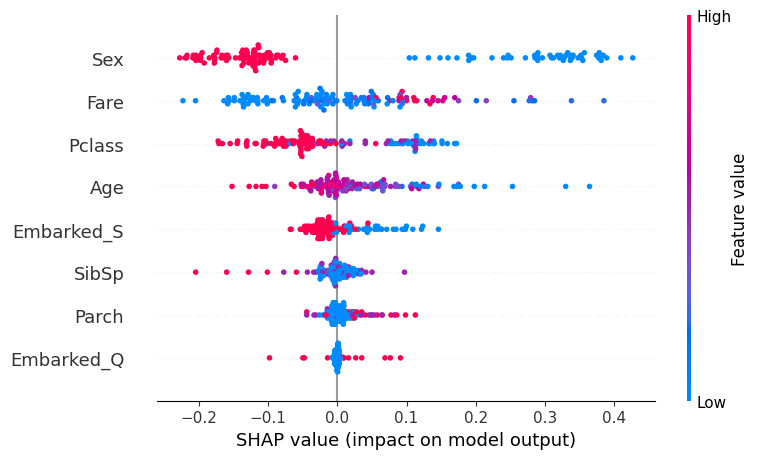

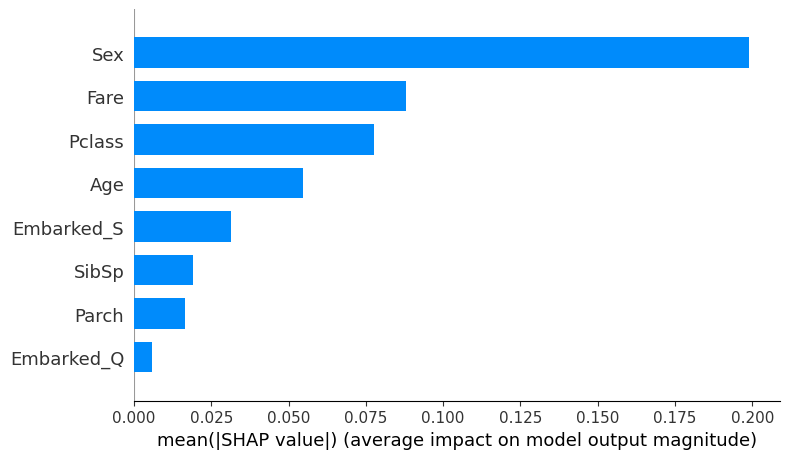


Top features by mean |SHAP|:
       feature  mean_abs_shap
0         Sex       0.199021
1        Fare       0.087943
2      Pclass       0.077600
3         Age       0.054644
4  Embarked_S       0.031453
5       SibSp       0.019032
6       Parch       0.016330
7  Embarked_Q       0.005740

Top-3 features for dependence plots: ['Sex', 'Fare', 'Pclass']

Dependence plot for Sex (colored by Pclass)


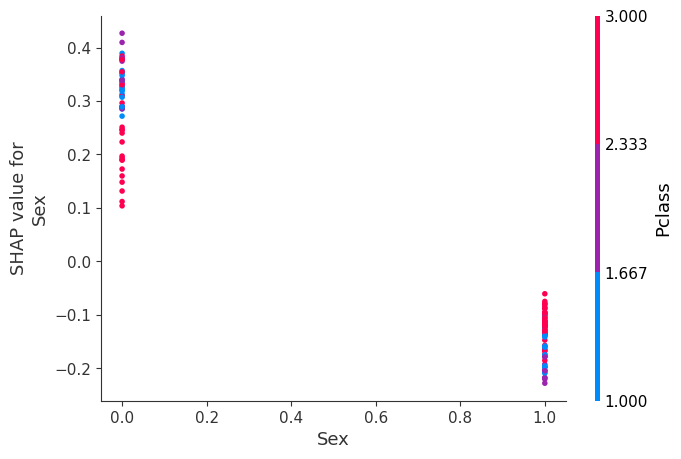


Dependence plot for Fare (colored by Age)


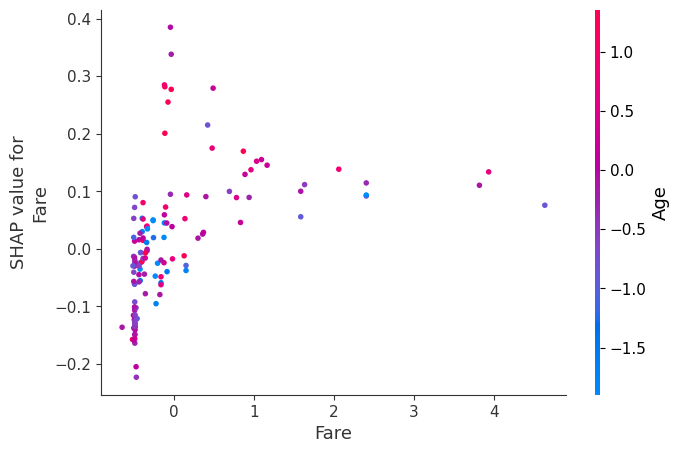


Dependence plot for Pclass (colored by Sex)


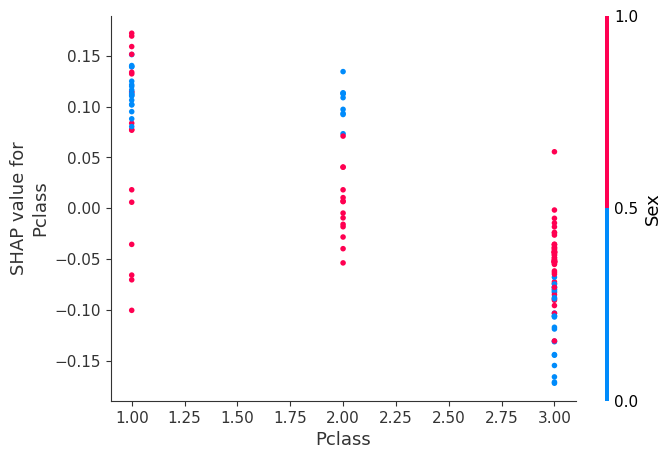

In [34]:
# Convert features to float to ensure SHAP compatibility
X_train_numeric = X_train.astype(float)
X_val_numeric = X_val.astype(float)

# Initialize TreeExplainer
explainer = shap.TreeExplainer(rf_clf, X_train_numeric, feature_perturbation="interventional")

# Calculate SHAP values for the validation set
shap_values = explainer(X_val_numeric, check_additivity=False)

# Extract SHAP values for Class 1 (Survived)
shap_values_class1 = shap_values.values[:, :, 1]

# --- 1. Global Summary Plot (Dot) ---
shap.summary_plot(
    shap_values_class1,
    X_val_numeric,
    feature_names=X_val.columns,
    max_display=8,
    show=True
)

# --- 2. Feature Importance (Bar) ---
shap.summary_plot(
    shap_values_class1,
    X_val_numeric,
    feature_names=X_val.columns,
    plot_type='bar',
    max_display=8,
    show=True
)

# --- 3. Extract Top Features ---
shap_importance = pd.DataFrame({
    "feature": X_val.columns,
    "mean_abs_shap": np.abs(shap_values_class1).mean(axis=0)
}).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)

print("\nTop features by mean |SHAP|:\n", shap_importance)

# --- 4. Dependence Plots for Top 3 Features ---
top_3_feats = shap_importance['feature'].iloc[:3].tolist()
print("\nTop-3 features for dependence plots:", top_3_feats)

interaction_dict = {
    'Sex': 'Pclass',
    'Fare': 'Age',
    'Pclass': 'Sex'
}

for feat in top_3_feats:
    color_feat = interaction_dict.get(feat, 'auto')
    print(f"\nDependence plot for {feat} (colored by {color_feat})")
    shap.dependence_plot(feat, shap_values_class1, X_val_numeric, interaction_index=color_feat, show=True)


In [ ]:
# Phase 4: Local Interpretability with LIME
# While SHAP explains global behavior, LIME (Local Interpretable Model-agnostic Explanations) 
# helps us understand the model's decision-making process for a *single specific instance*.


LIME explanation for test instance index 5:

Sex        | value:  0.734 | effect on prediction: -0.591
Fare       | value: -0.489 | effect on prediction: -0.075
Age        | value: -0.680 | effect on prediction: +0.069
Embarked_S | value:  0.605 | effect on prediction: -0.064
Parch      | value: -0.461 | effect on prediction: -0.038
SibSp      | value: -0.465 | effect on prediction: -0.010
Embarked_Q | value: -0.276 | effect on prediction: +0.007
Pclass     | value:  0.838 | effect on prediction: -0.001


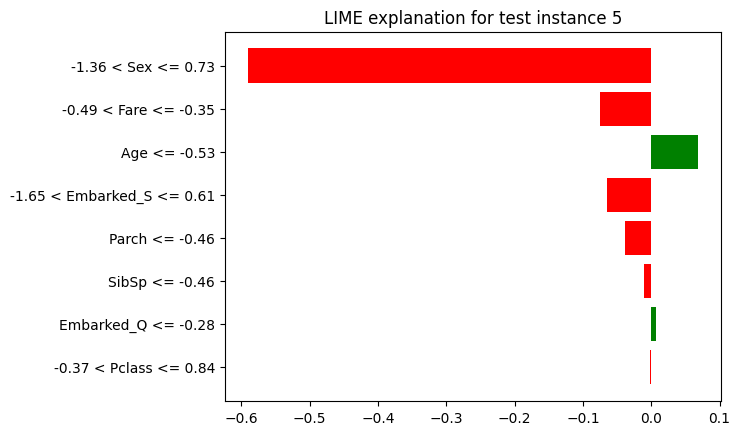

In [40]:
from lime.lime_tabular import LimeTabularExplainer
import warnings
import matplotlib.pyplot as plt

# Data scaling for LIME (like RandomForest)
scaler_val = StandardScaler()
X_train_scaled = pd.DataFrame(scaler_val.fit_transform(X_train), columns=X_train.columns)
X_val_scaled = pd.DataFrame(scaler_val.transform(X_val), columns=X_val.columns)

# Initialize LIME Explainer using the exact training data structure
lime_explainer = LimeTabularExplainer(
    training_data=np.array(X_train_scaled),
    feature_names=X_train.columns,
    class_names=["Did not survive", "Survived"],
    mode='classification'
)

# Select a specific instance from the validation set
i = 5

# Generate local explanation
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    exp = lime_explainer.explain_instance(
        X_val_scaled.iloc[i].values,  # 1D масив
        rf_clf.predict_proba,
        num_features=8
    )

# --- Output textual explanation ---
exp_map = exp.as_map()[1]  # for class 1 (Survived)

print(f"\nLIME explanation for test instance index {i}:\n")
for feat_idx, effect in exp_map:
    feat_name = X_val_scaled.columns[feat_idx]        # ім'я ознаки
    feat_value = X_val_scaled.iloc[i, feat_idx]       # значення ознаки
    print(f"{feat_name:10} | value: {feat_value:>6.3f} | effect on prediction: {effect:+.3f}")


# --- Plot LIME Bar Chart ----
fig = exp.as_pyplot_figure()
plt.title(f"LIME explanation for test instance {i}")
plt.show()
